In [1]:
%pip cache purge
%pip install -r ../requirements.txt


Files removed: 0 (0 bytes)
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://pypi.python.org/simple
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import os
import shutil

import warnings
from time import time
import seaborn as sns
sns.set(rc={'figure.figsize':(12,8)})

# mne import
import mne
from mne import Epochs, pick_types, events_from_annotations
from mne.io import concatenate_raws
from mne.io.edf import read_raw_edf
from mne.datasets import eegbci
from mne.preprocessing import (ICA, create_eog_epochs, create_ecg_epochs, corrmap, Xdawn)
from mne.time_frequency import AverageTFR
from mne.channels import make_standard_montage
from mne.decoding import LinearModel, Vectorizer, get_coef, Scaler, CSP, SPoC, UnsupervisedSpatialFilter
# from mne.time_frequency import psd_welch
mne.set_log_level('WARNING')

import sklearn
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn import datasets
from sklearn.model_selection import train_test_split


In [3]:
DIRECTORIES = [
    "../models", 
    "../data/raw/files",
	"../plots",
]
deleted_files = []

for directory in DIRECTORIES:
    if not os.path.exists(directory):
        print(f"Directory '{directory}' does not exist.")
        continue

    for item in os.listdir(directory):
        item_path = os.path.join(directory, item)

        if item == ".gitkeep":
            continue  # Skip .gitkeep

        if os.path.isfile(item_path):
            os.remove(item_path)
            deleted_files.append(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)
            deleted_files.append(item_path + "/")  

if deleted_files:
    print("Deleted files and directories:")
    for file in deleted_files:
        print(f" - {file}")
else:
    print("No files to delete.")


Deleted files and directories:
 - ../data/raw/files/MNE-eegbci-data/


In [4]:
subject = [1,2,3] # 1, 4
run_execution = [5, 9, 13]
# run_imagery = [6, 10, 14]

raw_files = []

for person_number in subject:
    for i in run_execution:
        raw_files_execution = [read_raw_edf(f, preload=True, stim_channel='auto') for f in eegbci.load_data(person_number, i)]
        # raw_files_imagery = [read_raw_edf(f, preload=True, stim_channel='auto') for f in eegbci.load_data(person_number, j)]
        
        raw_execution = concatenate_raws(raw_files_execution)
        # raw_imagery = concatenate_raws(raw_files_imagery)

        events, _ = mne.events_from_annotations(raw_execution, event_id=dict(T0=1,T1=2,T2=3))
        mapping = {1:'rest', 2: 'do/feet', 3: 'do/hands'}
        annot_from_events = mne.annotations_from_events(
            events=events, event_desc=mapping, sfreq=raw_execution.info['sfreq'],
            orig_time=raw_execution.info['meas_date'])
        raw_execution.set_annotations(annot_from_events)
        
        # events, _ = mne.events_from_annotations(raw_imagery, event_id=dict(T0=1,T1=2,T2=3))
        # mapping = {1:'rest', 2: 'imagine/feet', 3: 'imagine/hands'}
        # annot_from_events = mne.annotations_from_events(
        #     events=events, event_desc=mapping, sfreq=raw_imagery.info['sfreq'],
        #     orig_time=raw_imagery.info['meas_date'])
        # raw_imagery.set_annotations(annot_from_events)
        
        
        raw_files.append(raw_execution)
        # raw_files.append(raw_imagery)


In [5]:
raw_files


[<RawEDF | S001R05.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S001R09.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S001R13.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S002R05.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S002R09.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S002R13.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>,
 <RawEDF | S003R05.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S003R09.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>,
 <RawEDF | S003R13.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>]

In [6]:
raw = concatenate_raws(raw_files)
events, event_dict = mne.events_from_annotations(raw)
print(raw.info)
print(event_dict)


<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>
{'do/feet': 1, 'do/hands': 2, 'rest': 3}


In [7]:
picks = pick_types(raw.info, meg=False, eeg=True, stim=False, eog=False, exclude='bads')
print (picks)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63]


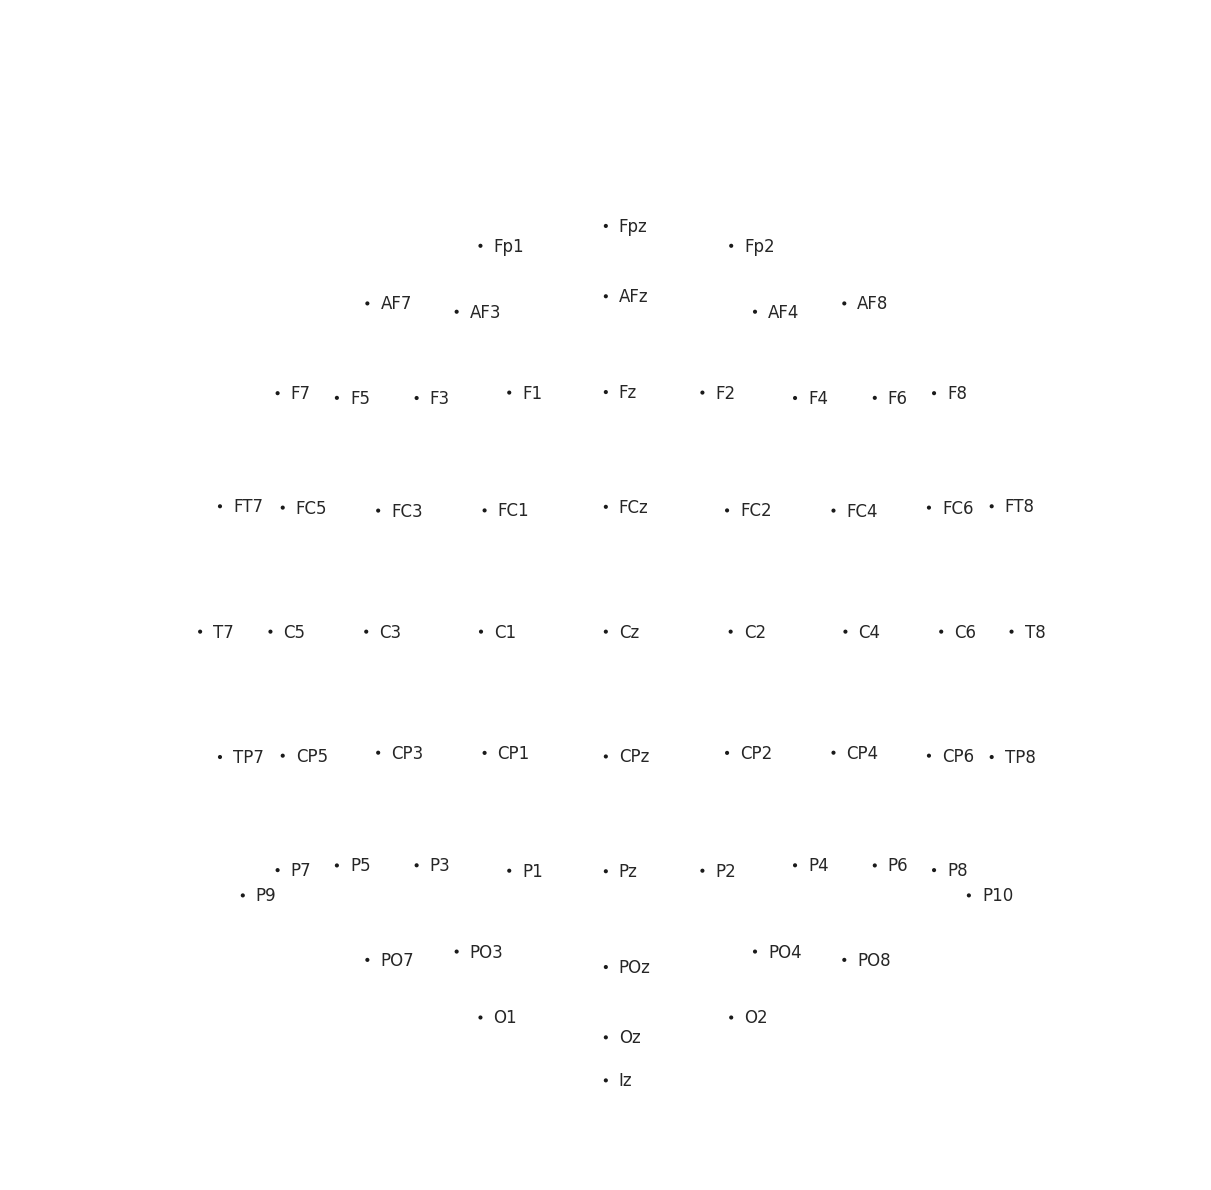

In [8]:
biosemi_montage = mne.channels.make_standard_montage('biosemi64')
biosemi_montage.plot()
plt.show()


In [9]:
eegbci.standardize(raw)  # set channel names
montage = make_standard_montage('standard_1005')
raw.set_montage(montage)


<RawEDF | S001R05.edf, 64 x 179040 (1119.0 s), ~87.5 MiB, data loaded>

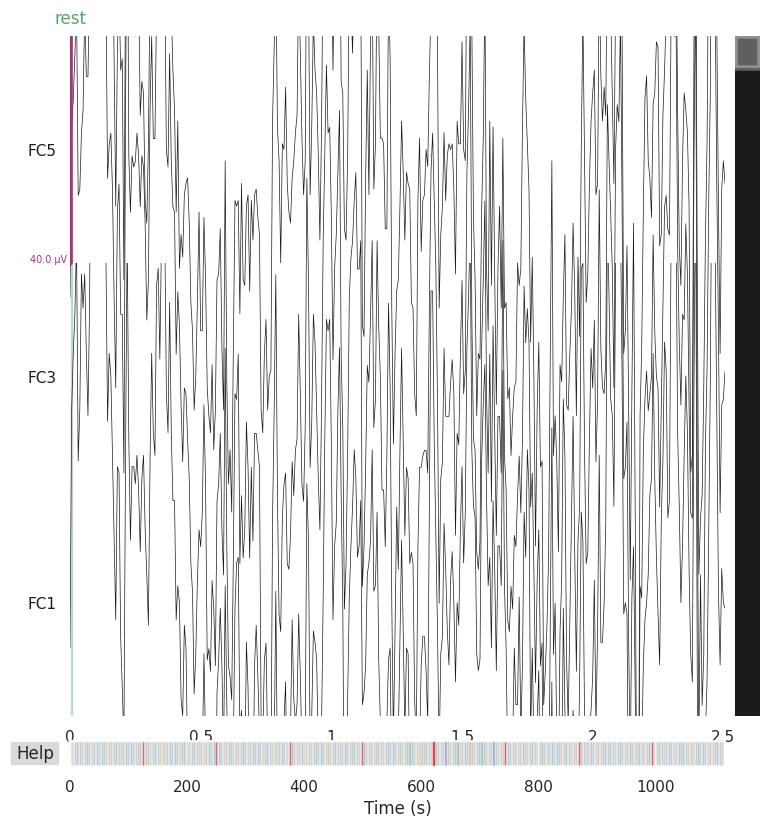

In [10]:
raw.plot(n_channels=3, duration = 2.5)
plt.show()


/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


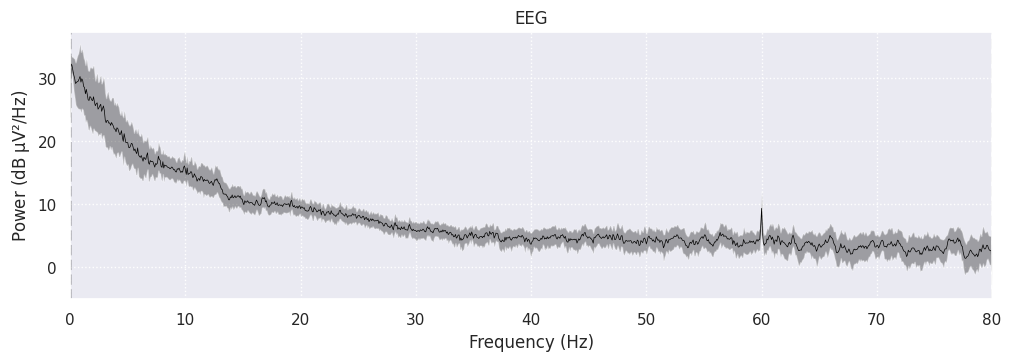

In [11]:
raw.plot_psd(average=True)
plt.show()


/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


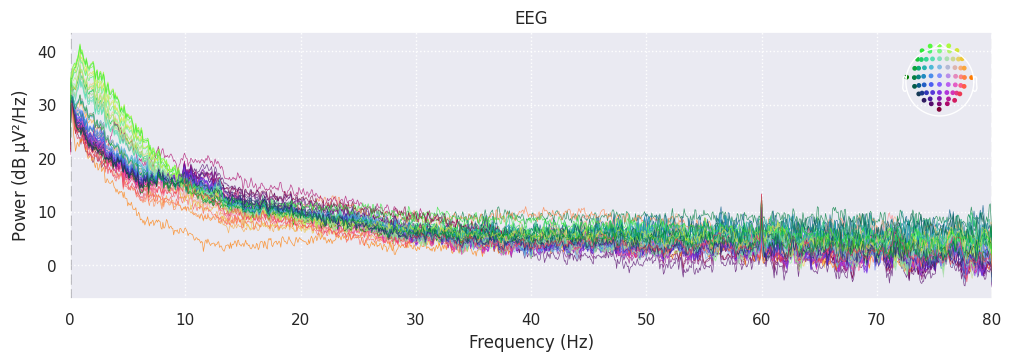

In [12]:
raw.plot_psd(average=False)
plt.show()


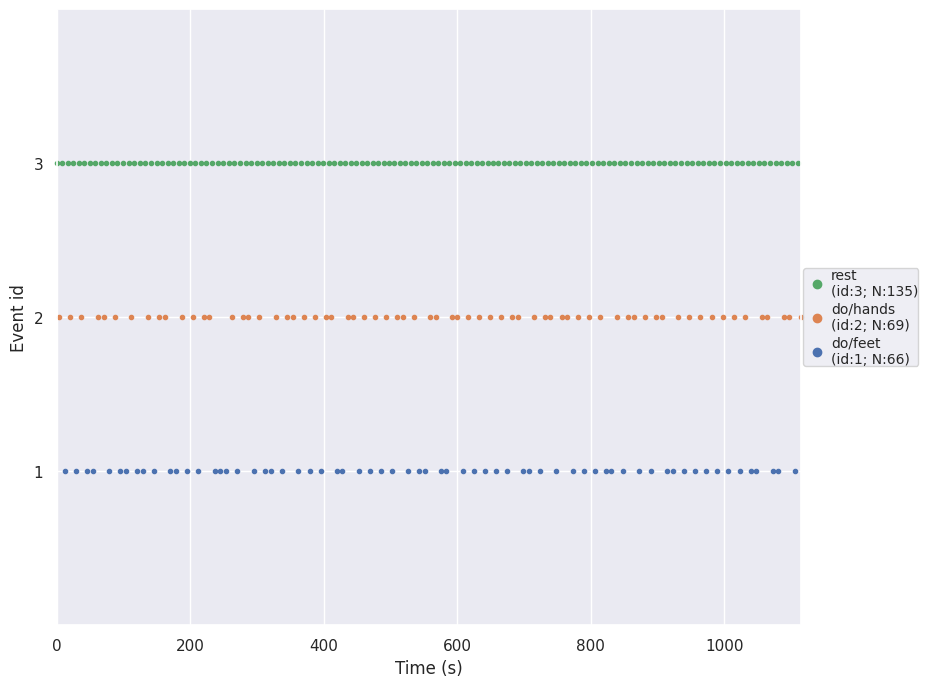

/tmp/ipykernel_1698649/4089939616.py:3: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.7)  # make room for legend


In [13]:
fig = mne.viz.plot_events(events, sfreq=raw.info['sfreq'],
                          first_samp=raw.first_samp, event_id=event_dict)
fig.subplots_adjust(right=0.7)  # make room for legend


In [14]:
raw.filter(8., 40., fir_design='firwin', skip_by_annotation='edge')


<RawEDF | S001R05.edf, 64 x 179040 (1119.0 s), ~87.5 MiB, data loaded>

/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


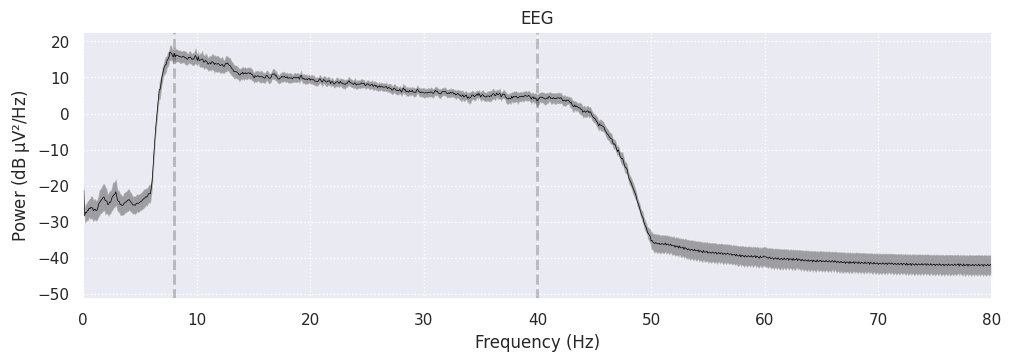

In [15]:
raw.plot_psd(average=True)
plt.show()


/sgoinfre/students/dgerwig-/miniforge/envs/vortex_env/lib/python3.11/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


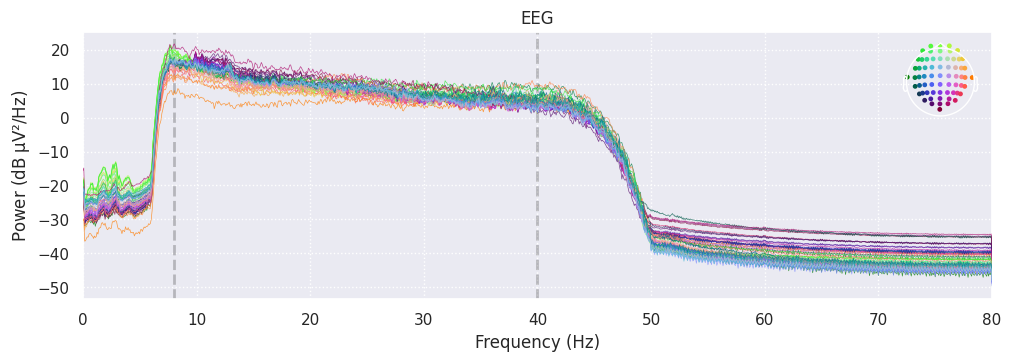

In [16]:
raw.plot_psd(average=False)
plt.show()


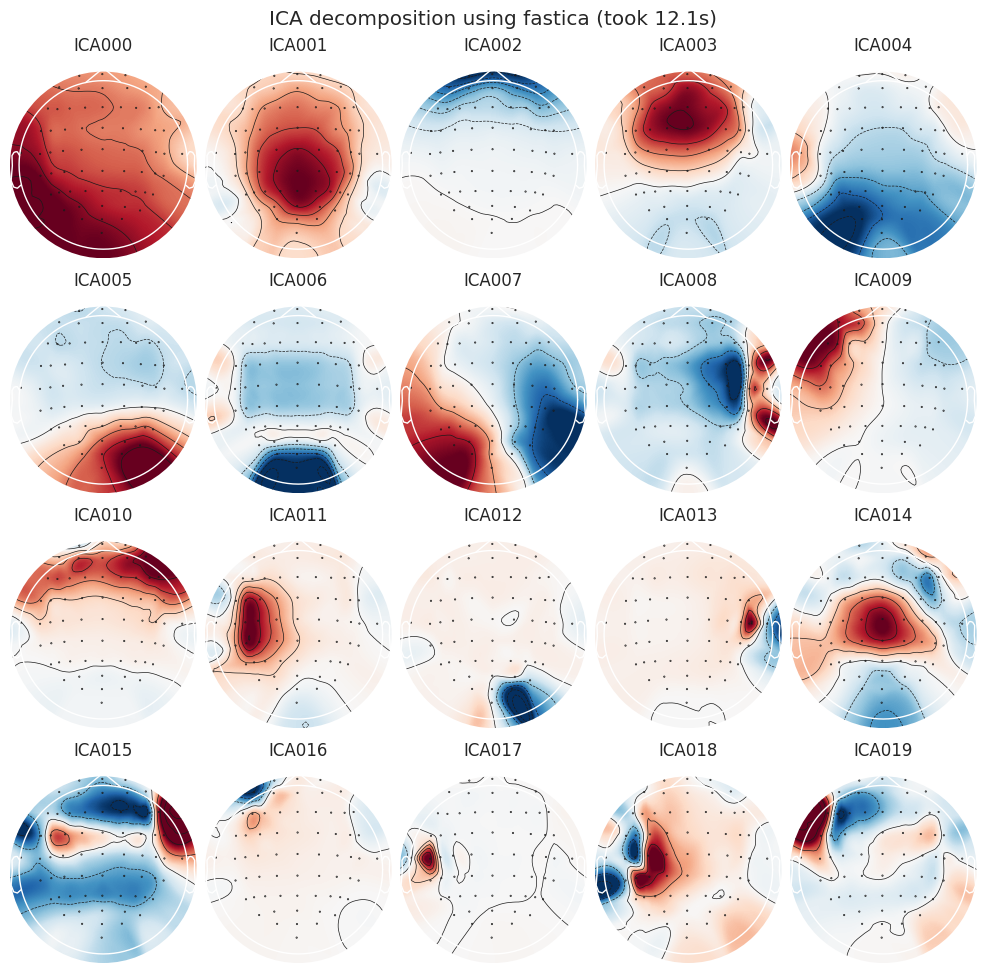

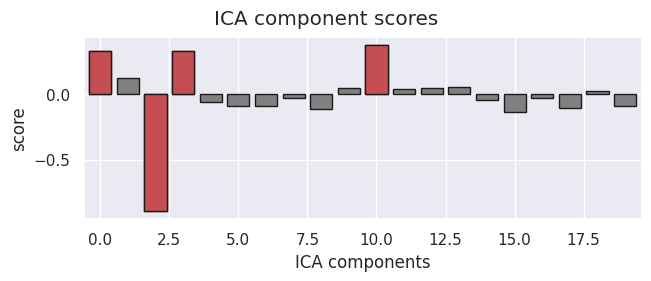

[2, 10, 0, 3] {'eog/0/Fpz': [0, 2, 3, 10], 'eog': [2, 10, 0, 3]}


In [17]:
def run_ica(raw, method, fit_params=None):
    raw_corrected = raw.copy()
    n_components=20
    
    ica = ICA(n_components=n_components, method=method, fit_params=fit_params, random_state=97)
    t0 = time()
    ica.fit(raw_corrected, picks=picks)
    fit_time = time() - t0
    title = ('ICA decomposition using %s (took %.1fs)' % (method, fit_time))
    ica.plot_components(title=title)
    plt.show()
    
    eog_indices, scores = ica.find_bads_eog(raw, ch_name='Fpz',threshold=1.5)
    ica.plot_scores(scores, exclude=eog_indices)  # look at r scores of components
    ica.exclude.extend(eog_indices) 
    raw_corrected = ica.apply(raw_corrected, n_pca_components = n_components, exclude = ica.exclude)
    print(ica.exclude, ica.labels_)
    return raw_corrected

raw_fastica = run_ica(raw, 'fastica')


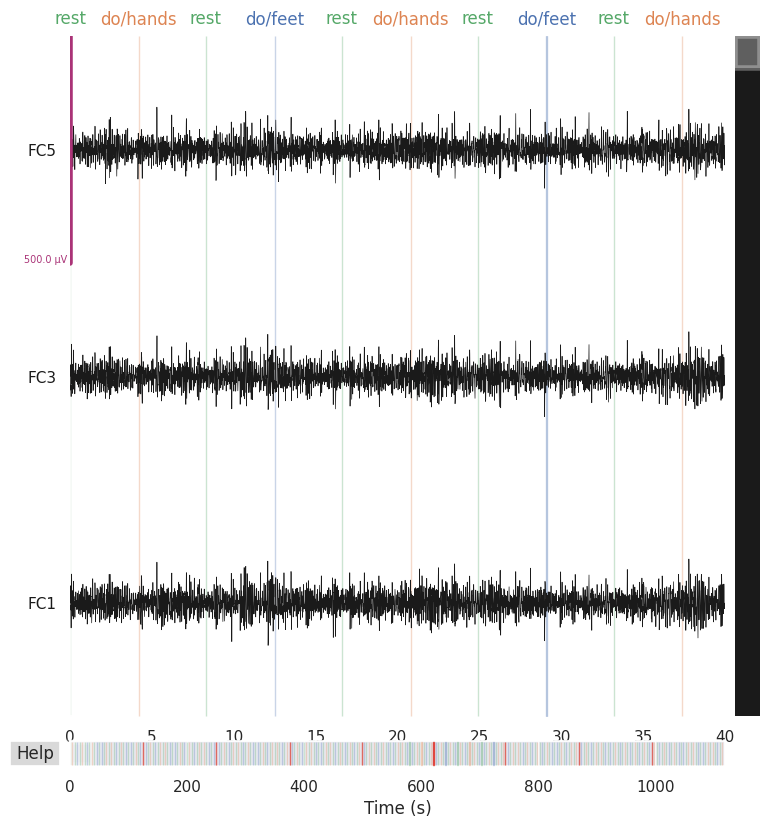

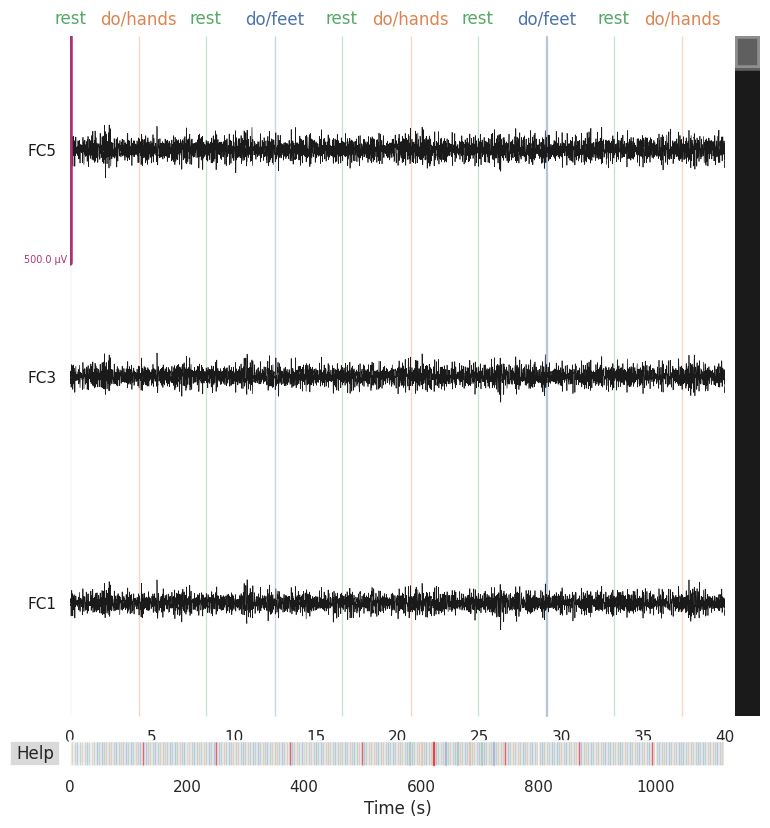

In [18]:
raw.plot(n_channels=3, start=0, duration=40,scalings=dict(eeg=250e-6))
raw_fastica.plot(n_channels=3, start=0, duration=40,scalings=dict(eeg=250e-6))
plt.show()


In [19]:
# event_id = {'do/feet': 1, 'do/hands': 2, 'imagine/feet': 3, 'imagine/hands': 4}
event_id = {'do/feet': 1, 'do/hands': 2}


In [20]:
tmin, tmax = -1., 4.

events, event_dict = mne.events_from_annotations(raw, event_id=event_id)
print (event_dict)


{'do/feet': 1, 'do/hands': 2}


In [21]:
picks


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63])

In [22]:
epochs = Epochs(raw, events, event_id, tmin, tmax, proj=True, picks=picks, baseline=None, preload=True)
epochs


<Epochs | 135 events (all good), -1 – 4 s (baseline off), ~52.9 MiB, data loaded,
 'do/feet': 66
 'do/hands': 69>

In [23]:
labels = epochs.events[:, -1] - 1
labels


array([1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1])

In [24]:
# evoked = epochs['imagine/feet'].average()
# evoked.plot_joint(title='Average Reference', show=False)
# plt.show()


In [25]:
# evoked = epochs['imagine/hands'].average()
# evoked.plot_joint(title='Average Reference', show=False)
# plt.show()


In [26]:
# %matplotlib qt 
# times = np.arange(-1, 4, 0.1)
# fig, anim = evoked.animate_topomap(times=times, ch_type='eeg', frame_rate=2, time_unit='s', blit=False)


In [27]:
# %matplotlib inline
# sns.set(rc={'figure.figsize':(12,8)})


# PIPELINE

In [28]:
# score_pipeline = -1
# models_pipeline = None


Shape of epochs_data: (135, 64, 801)
No existing score_pipeline found, will create a new one.
Testing CSP + LDA...
CSP + LDA - Accuracy: 0.6889 (± 0.1525)
Testing CSP + LogReg...
CSP + LogReg - Accuracy: 0.5852 (± 0.1274)
Testing CSP + RF...
CSP + RF - Accuracy: 0.8148 (± 0.1689)
Testing PCA + LDA...
PCA + LDA - Accuracy: 0.4963 (± 0.1374)
Testing PCA + LogReg...
PCA + LogReg - Accuracy: 0.4148 (± 0.1274)
Testing PCA + RF...
PCA + RF - Accuracy: 0.4222 (± 0.1790)


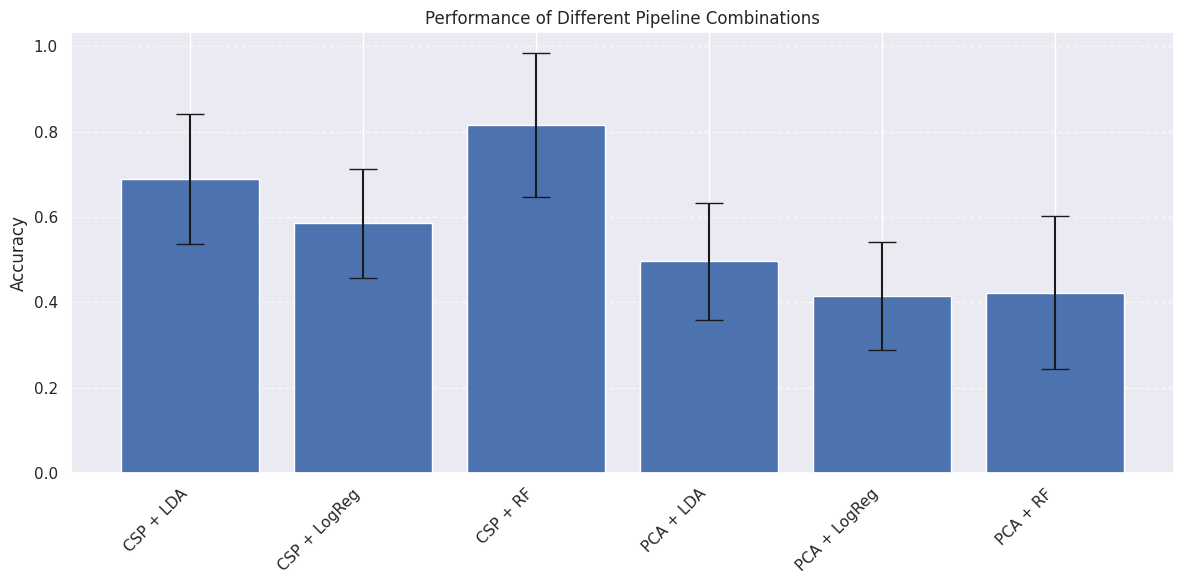


Best combination:
CSP + RF - Accuracy: 0.8148 (± 0.1689)
New best pipeline found! Accuracy: 0.8148


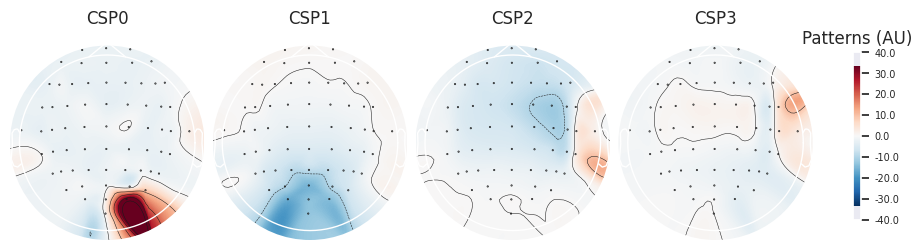

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import ShuffleSplit, cross_val_score
from sklearn.decomposition import PCA
from mne.decoding import CSP
from sklearn.base import BaseEstimator, TransformerMixin

# Use the epochs you already have in your environment
# This assumes you're running this code after your original code block
# that defines 'epochs' and 'labels'
epochs_data = epochs.get_data().astype(np.float64)

# Check the shape of the data
print(f"Shape of epochs_data: {epochs_data.shape}")
# We expect something like (n_epochs, n_channels, n_timepoints)

# Custom transformer to reshape 3D data to 2D for PCA
class Reshaper(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.original_shape = None
        
    def fit(self, X, y=None):
        self.original_shape = X.shape
        return self
        
    def transform(self, X):
        # Reshape from (n_epochs, n_channels, n_timepoints) to (n_epochs, n_channels*n_timepoints)
        n_epochs = X.shape[0]
        return X.reshape(n_epochs, -1)
    
    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

# Define the components to test
feature_extractors = {
    'CSP': CSP(n_components=4, reg=None, log=True, norm_trace=False, cov_est='concat'),
    'PCA': make_pipeline(Reshaper(), PCA(n_components=10))  # Use reshaper before PCA
}

classifiers = {
    'LDA': LinearDiscriminantAnalysis(solver='svd'),
    'LogReg': LogisticRegression(max_iter=1000, random_state=42),
    'RF': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Define cross-validation strategy
cv = ShuffleSplit(5, test_size=0.2)

# Store results
results = {}
best_score = 0
best_pipeline = None

# Track best performance to update your current best model if needed
score_pipeline_current = -1  # Initialize with a negative value if not defined
try:
    # Try to use existing score_pipeline if it exists
    score_pipeline_current = score_pipeline
except NameError:
    print("No existing score_pipeline found, will create a new one.")

# Test all combinations
for feat_name, feat_transformer in feature_extractors.items():
    for clf_name, classifier in classifiers.items():
        combo_name = f"{feat_name} + {clf_name}"
        print(f"Testing {combo_name}...")
        
        # Create pipeline
        pipeline = make_pipeline(feat_transformer, classifier)
        
        try:
            # Calculate cross-validation score with error handling
            scores = cross_val_score(pipeline, epochs_data, labels, cv=cv, n_jobs=1)
            
            # Store results
            results[combo_name] = {
                'mean': scores.mean(), 
                'std': scores.std(),
                'pipeline': pipeline
            }
            
            # Check if this is the best pipeline so far
            if scores.mean() > best_score:
                best_score = scores.mean()
                best_pipeline = pipeline
            
            # Print results for this combination
            print(f"{combo_name} - Accuracy: {scores.mean():.4f} (± {scores.std() * 2:.4f})")
            
        except Exception as e:
            print(f"Error with {combo_name}: {str(e)}")
            continue

# Only plot if we have results
if results:
    # Plot results
    plt.figure(figsize=(12, 6))
    combinations = list(results.keys())
    means = [results[combo]['mean'] for combo in combinations]
    stds = [results[combo]['std'] * 2 for combo in combinations]

    plt.bar(combinations, means, yerr=stds, capsize=10)
    plt.ylabel('Accuracy')
    plt.title('Performance of Different Pipeline Combinations')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Print the best combination
    best_combo = max(results.items(), key=lambda x: x[1]['mean'])
    print("\nBest combination:")
    print(f"{best_combo[0]} - Accuracy: {best_combo[1]['mean']:.4f} (± {best_combo[1]['std'] * 2:.4f})")

    # Update score_pipeline and models_pipeline if the new best score is better
    try:
        if best_score > score_pipeline_current:
            print(f"New best pipeline found! Accuracy: {best_score:.4f}")
            score_pipeline = best_score
            models_pipeline = best_pipeline
        else:
            print(f"No improvement over current best pipeline ({score_pipeline_current:.4f})")
    except NameError:
        print("Creating new score_pipeline with value:", best_score)
        score_pipeline = best_score
        models_pipeline = best_pipeline

    # If you want to visualize CSP patterns for the best model (if it uses CSP)
    if 'CSP' in best_combo[0]:
        try:
            # Get the CSP step from the pipeline
            if hasattr(best_pipeline, 'named_steps') and 'csp' in best_pipeline.named_steps:
                csp = best_pipeline.named_steps['csp']
                # Fit CSP on the full data
                csp.fit_transform(epochs_data, labels)
                # Plot patterns
                csp.plot_patterns(epochs.info, ch_type='eeg', units='Patterns (AU)', size=1.5)
                plt.show()
            else:
                # Try to find CSP component by type
                for step_name, step in best_pipeline.named_steps.items():
                    if isinstance(step, CSP):
                        step.fit_transform(epochs_data, labels)
                        step.plot_patterns(epochs.info, ch_type='eeg', units='Patterns (AU)', size=1.5)
                        plt.show()
                        break
                else:
                    print("Could not find CSP step in pipeline to visualize patterns")
        except Exception as e:
            print(f"Error visualizing CSP patterns: {str(e)}")
else:
    print("No successful pipeline combinations to report.")


In [30]:
score_pipeline


0.8148148148148149

In [31]:
models_pipeline


Pipeline(steps=[('csp', CSP(log=True)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [32]:
x_train, x_test, y_train, y_test = train_test_split(epochs_data, labels, test_size=0.2, shuffle=True)
models_pipeline.fit(x_train, y_train)


Pipeline(steps=[('csp', CSP(log=True)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [33]:
models_pipeline.predict(x_test)


array([0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0])

Valores reales (y_test):
[0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 1 1 0 0 0 1 1 1 1 1 1 0]

Valores predichos (y_pred):
[0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1 0 0 1 1 1 1 1 0 0]

Precisión del modelo: 0.7778
Score del modelo: 0.7778

Informe de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        14
           1       0.77      0.77      0.77        13

    accuracy                           0.78        27
   macro avg       0.78      0.78      0.78        27
weighted avg       0.78      0.78      0.78        27



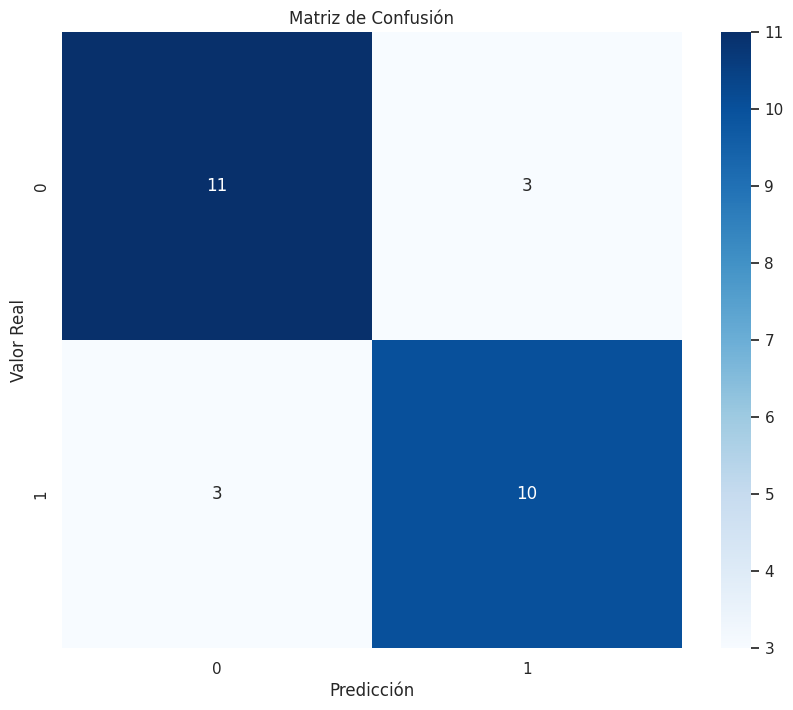


Índices donde hubo errores de predicción: [ 6  7 10 12 17 25]
Total de errores: 6 de 27 (22.22%)


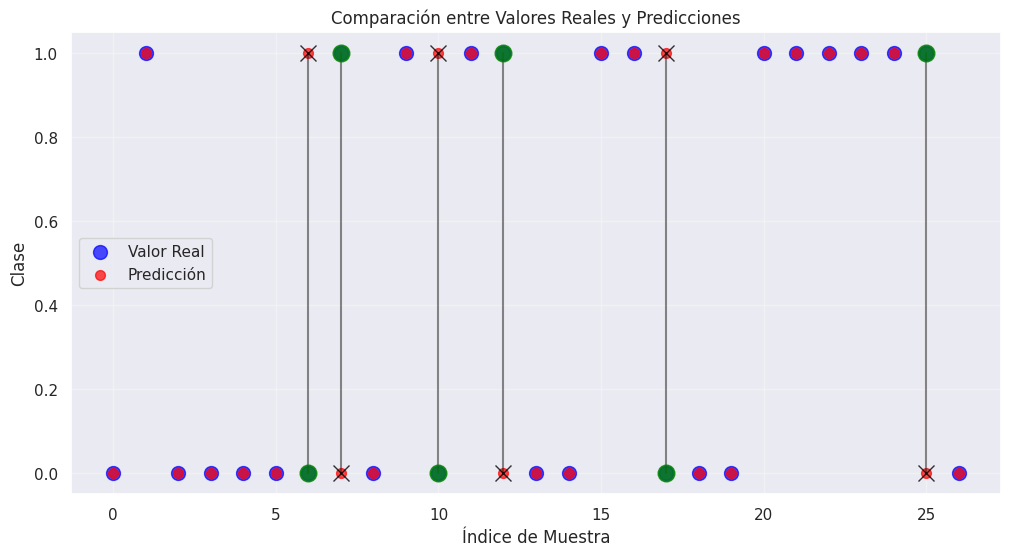


Tabla de comparación:
Índice | Valor Real | Predicción | ¿Correcto?
---------------------------------------------
     0 |          0 |          0 |     ✓     
     1 |          1 |          1 |     ✓     
     2 |          0 |          0 |     ✓     
     3 |          0 |          0 |     ✓     
     4 |          0 |          0 |     ✓     
     5 |          0 |          0 |     ✓     
     6 |          0 |          1 |     ✗     
     7 |          1 |          0 |     ✗     
     8 |          0 |          0 |     ✓     
     9 |          1 |          1 |     ✓     
    10 |          0 |          1 |     ✗     
    11 |          1 |          1 |     ✓     
    12 |          1 |          0 |     ✗     
    13 |          0 |          0 |     ✓     
    14 |          0 |          0 |     ✓     
    15 |          1 |          1 |     ✓     
    16 |          1 |          1 |     ✓     
    17 |          0 |          1 |     ✗     
    18 |          0 |          0 |     ✓     
    19 |   

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

# Obtener predicciones del modelo
y_pred = models_pipeline.predict(x_test)

# Imprimir valores reales y predicciones
print("Valores reales (y_test):")
print(y_test)
print("\nValores predichos (y_pred):")
print(y_pred)

# Calcular y mostrar precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrecisión del modelo: {accuracy:.4f}")
print(f"Score del modelo: {models_pipeline.score(x_test, y_test):.4f}")

# Crear informe de clasificación
print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred))

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred)
class_names = np.unique(np.concatenate([y_test, y_pred]))

# Visualizar matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

# Comparar predicciones vs valores reales (visualización)
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Valor Real', alpha=0.7, s=100)
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicción', alpha=0.7, s=50)
plt.xlabel('Índice de Muestra')
plt.ylabel('Clase')
plt.title('Comparación entre Valores Reales y Predicciones')
plt.legend()
plt.grid(True, alpha=0.3)

# Mostrar errores en la predicción
incorrect = np.where(y_test != y_pred)[0]
if len(incorrect) > 0:
    print(f"\nÍndices donde hubo errores de predicción: {incorrect}")
    print(f"Total de errores: {len(incorrect)} de {len(y_test)} ({len(incorrect)/len(y_test)*100:.2f}%)")
    
    # Resaltar errores en el gráfico
    for idx in incorrect:
        plt.plot([idx, idx], [y_test[idx], y_pred[idx]], 'k-', alpha=0.5)
        plt.plot(idx, y_test[idx], 'o', color='green', alpha=0.8, markersize=12)
        plt.plot(idx, y_pred[idx], 'x', color='black', alpha=0.8, markersize=12)

plt.show()

# Tabla de comparación de valores reales y predicciones
n_samples = len(y_test)
comparison_table = np.column_stack((y_test[:n_samples], y_pred[:n_samples]))
print("\nTabla de comparación:")
print("Índice | Valor Real | Predicción | ¿Correcto?")
print("-" * 45)
for i in range(n_samples):
    is_correct = "✓" if y_test[i] == y_pred[i] else "✗"
    print(f"{i:6d} | {y_test[i]:10} | {y_pred[i]:10} | {is_correct:^10}")


In [39]:
models_pipeline.score(x_test, y_test)


0.7777777777777778